In [396]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import random
from nilearn.glm.first_level import compute_regressor
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix

In [397]:
# Now set ITI etc
trial_number = 20
median_iti = 5.5

onset=[0]
for i in range(1, trial_number):
    onset.append(onset[i-1] + random.uniform(median_iti - 1, median_iti + 1))
amplitude, duration = [1] * trial_number, [1] * trial_number
exp_condition = np.array((onset, duration, amplitude)).reshape(3, len(onset))
print(onset)

[0, 5.81993840017325, 11.710012451661385, 17.514780035985567, 23.954479905360394, 29.467325566560266, 35.91108344112141, 42.0922016441347, 47.63005316203495, 53.825211237849004, 59.23245938669198, 64.42714677690944, 69.49272976008947, 74.45731051980297, 80.34463383023282, 86.09431650250262, 91.75414082289814, 97.27674091372785, 103.0058168884499, 108.61358200126581]


In [398]:
# Scanner info
tr = 1.0  # repetition time is 1 second

# Define timeframe
time_length = math.ceil(max(onset))
points_per_second = 4 # resolution
frame_times = np.linspace(0, time_length, (points_per_second * time_length + 1))
n_scans = len(frame_times)
print(frame_times)

[  0.     0.25   0.5    0.75   1.     1.25   1.5    1.75   2.     2.25
   2.5    2.75   3.     3.25   3.5    3.75   4.     4.25   4.5    4.75
   5.     5.25   5.5    5.75   6.     6.25   6.5    6.75   7.     7.25
   7.5    7.75   8.     8.25   8.5    8.75   9.     9.25   9.5    9.75
  10.    10.25  10.5   10.75  11.    11.25  11.5   11.75  12.    12.25
  12.5   12.75  13.    13.25  13.5   13.75  14.    14.25  14.5   14.75
  15.    15.25  15.5   15.75  16.    16.25  16.5   16.75  17.    17.25
  17.5   17.75  18.    18.25  18.5   18.75  19.    19.25  19.5   19.75
  20.    20.25  20.5   20.75  21.    21.25  21.5   21.75  22.    22.25
  22.5   22.75  23.    23.25  23.5   23.75  24.    24.25  24.5   24.75
  25.    25.25  25.5   25.75  26.    26.25  26.5   26.75  27.    27.25
  27.5   27.75  28.    28.25  28.5   28.75  29.    29.25  29.5   29.75
  30.    30.25  30.5   30.75  31.    31.25  31.5   31.75  32.    32.25
  32.5   32.75  33.    33.25  33.5   33.75  34.    34.25  34.5   34.75
  35. 

In [399]:
# these are the types of the different trials
conditions = ['angry', 'happy'] * int((trial_number/2))
duration = [0.1] * trial_number # 1 for feedback
# Next, we simulate 6 motion parameters jointly observed with fMRI acquisitions
motion = np.cumsum(np.random.randn(n_scans, 6), 0)
# The 6 parameters correspond to three translations and three
# rotations describing rigid body motion
add_reg_names = ["tx", "ty", "tz", "rx", "ry", "rz"]

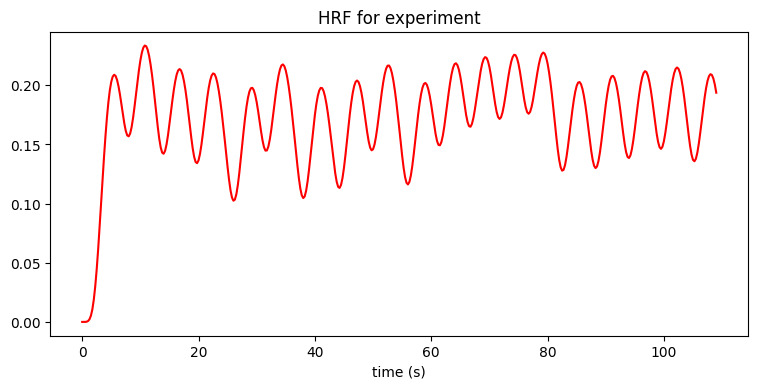

In [400]:
oversampling = 16

fig = plt.figure(figsize=(9, 4))

# compute signal of interest by convolution
signal, _labels = compute_regressor(
    exp_condition,
    "spm",
    frame_times,
    con_id="HRF",
    oversampling=oversampling,
)

plt.plot(
    frame_times,
    signal,
    label=_labels,
    color='r'
)
plt.xlabel("time (s)")
plt.title('HRF for experiment')

# adjust plot
plt.subplots_adjust(bottom=0.12)
plt.show()

In [401]:
events = pd.DataFrame(
    {"trial_type": conditions, "onset": onset, "duration": duration}
)

In [402]:
hrf_model = "glover"
X1 = make_first_level_design_matrix(
    frame_times,
    events,
    drift_model="polynomial",
    drift_order=3,
    add_regs=motion,
    add_reg_names=add_reg_names,
    hrf_model=hrf_model,
)

In [403]:
duration = 7.0 * np.ones(len(conditions))
events = pd.DataFrame(
    {"trial_type": conditions, "onset": onset, "duration": duration}
)

In [404]:
X2 = make_first_level_design_matrix(
    frame_times,
    events,
    drift_model="polynomial",
    drift_order=3,
    hrf_model=hrf_model,
)

In [405]:
events = pd.DataFrame(
    {"trial_type": conditions, "onset": onset, "duration": duration}
)
hrf_model = "FIR"
X3 = make_first_level_design_matrix(
    frame_times,
    events,
    hrf_model="fir",
    drift_model="polynomial",
    drift_order=3,
    fir_delays=np.arange(1, 6),
)

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_25585/2038522016.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


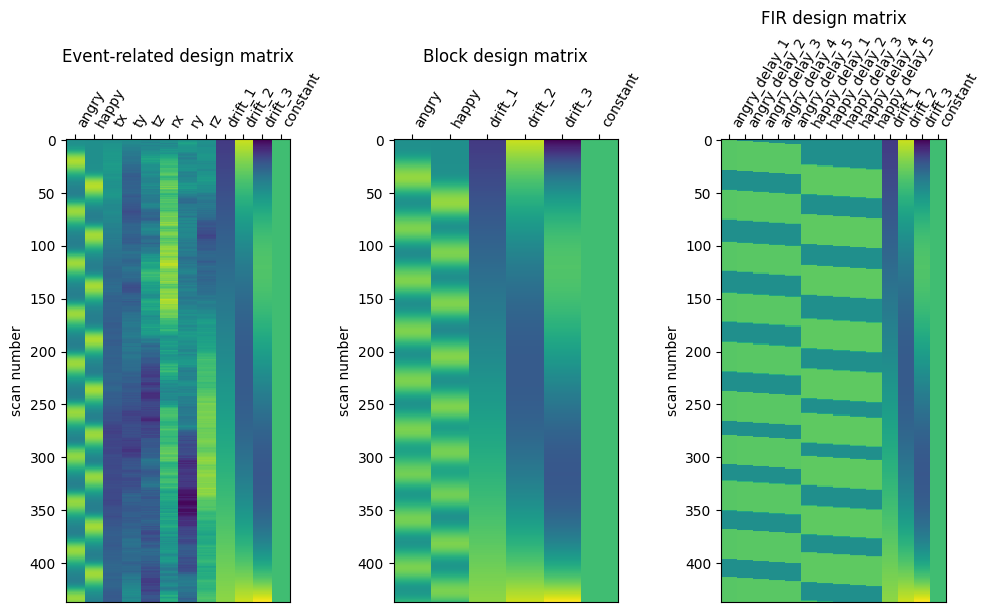

In [406]:
fig, (ax1, ax2, ax3) = plt.subplots(figsize=(10, 6), nrows=1, ncols=3)
plot_design_matrix(X1, ax=ax1)
ax1.set_title("Event-related design matrix", fontsize=12)
plot_design_matrix(X2, ax=ax2)
ax2.set_title("Block design matrix", fontsize=12)
plot_design_matrix(X3, ax=ax3)
ax3.set_title("FIR design matrix", fontsize=12)
fig.show()